Loaded scenario scenario_0_1.npz: obstacle=(np.int64(5), np.int64(9)), radius=0.7

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      158
Number of nonzeros in inequality constraint Jacobian.:       12
Number of nonzeros in Lagrangian Hessian.............:       20

Total number of variables............................:       62
                     variables with only lower bounds:        0
                variables with lower and upper bounds:       46
                     variables with only upper bounds:        0
Total numb

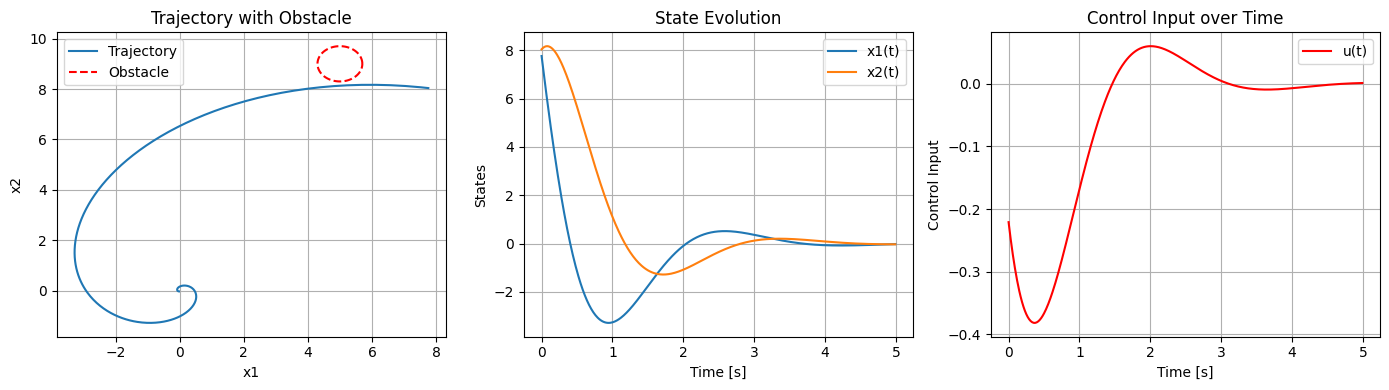

In [4]:
# ============================================================
# File: run_mpc_with_dataset.py
# Purpose: Run do-mpc simulations using dataset generated earlier
# ============================================================

import numpy as np
import do_mpc
from casadi import *
import matplotlib.pyplot as plt
import os

# ============================================================
# Load one scenario from dataset
# ============================================================
def load_scenario(dataset_dir, scenario_index=0):
    files = sorted([f for f in os.listdir(dataset_dir) if f.endswith('.npz')])
    if not files:
        raise FileNotFoundError(f"No .npz files found in {dataset_dir}")
    data = np.load(os.path.join(dataset_dir, files[scenario_index]))
    A = data['A']
    obstacle = {'center': tuple(data['obstacle_center']), 'radius': float(data['radius'])}
    print(f"Loaded scenario {files[scenario_index]}: obstacle={obstacle['center']}, radius={obstacle['radius']}")
    return A, obstacle


# ============================================================
# Build do-mpc model/controller/simulator for given scenario
# ============================================================
def create_mpc(A, obstacle, dt=0.01):
    model = do_mpc.model.Model('continuous')

    # Default B matrix for single-input system
    B = np.array([[0], [1]])

    # States and control
    x1 = model.set_variable(var_type='_x', var_name='x1', shape=(1, 1))
    x2 = model.set_variable(var_type='_x', var_name='x2', shape=(1, 1))
    u = model.set_variable(var_type='_u', var_name='u', shape=(1, 1))

    # Dynamics
    model.set_rhs('x1', A[0, 0]*x1 + A[0, 1]*x2 + B[0, 0]*u)
    model.set_rhs('x2', A[1, 0]*x1 + A[1, 1]*x2 + B[1, 0]*u)
    model.setup()

    # MPC setup
    mpc = do_mpc.controller.MPC(model)
    setup_mpc = {
        'n_horizon': 6,
        't_step': dt,
        'state_discretization': 'collocation',
        'collocation_type': 'radau',
        'store_full_solution': True,
    }
    mpc.set_param(**setup_mpc)

    # Cost function
    mterm = 10*x1**2 + x2**2
    lterm = 10*x1**2 + x2**2 + u**2
    mpc.set_objective(mterm=mterm, lterm=lterm)
    mpc.set_rterm(u=0)

    # Bounds
    mpc.bounds['lower', '_x', 'x1'] = -10
    mpc.bounds['upper', '_x', 'x1'] = 10
    mpc.bounds['lower', '_x', 'x2'] = -10
    mpc.bounds['upper', '_x', 'x2'] = 10
    mpc.bounds['lower', '_u', 'u'] = -5
    mpc.bounds['upper', '_u', 'u'] = 5

    # Obstacle constraint
    if obstacle is not None:
        cx, cy = obstacle['center']
        r = obstacle['radius']
        constraint = -((x1 - cx)**2 + (x2 - cy)**2) + r**2
        mpc.set_nl_cons('obstacle_constraint', constraint, ub=0)

    mpc.setup()

    # Simulator
    simulator = do_mpc.simulator.Simulator(model)
    params_sim = {'integration_tool': 'cvodes', 't_step': dt}
    simulator.set_param(**params_sim)
    simulator.setup()

    return model, mpc, simulator


# ============================================================
# Run simulation for loaded scenario
# ============================================================
def simulate_scenario(A, obstacle, dt=0.01, n_steps=500, x0=np.array([[8], [8]])):
    model, mpc, simulator = create_mpc(A, obstacle, dt)
    mpc.x0 = x0
    simulator.x0 = x0
    mpc.set_initial_guess()

    state_history = []
    input_history = []
    cost = 0

    lterm_func = Function('lterm_func', [model.x, model.u], [10*model.x['x1']**2 + model.x['x2']**2 + model.u['u']**2])
    mterm_func = Function('mterm_func', [model.x], [10*model.x['x1']**2 + model.x['x2']**2])

    for k in range(n_steps):
        u0 = mpc.make_step(x0)
        x_next = simulator.make_step(u0)

        x_next = np.array(x_next).reshape(-1, 1)
        u0 = np.array(u0).reshape(-1, 1)

        state_history.append(x_next.squeeze())
        input_history.append(u0.squeeze())
        cost += float(lterm_func(x_next, u0))

        x0 = x_next

    cost += float(mterm_func(x0))
    cost *= dt

    return np.array(state_history), np.array(input_history), cost


# ============================================================
# Example usage
# ============================================================
if __name__ == "__main__":
    dataset_dir = '/Users/apple/Documents/GitHub/System-1-and-System-2-in-Motion-Planning/Dataset/dataset_obstacle'
    A, obstacle = load_scenario(dataset_dir, scenario_index=1)

    dt = 0.01
    states, inputs, cost = simulate_scenario(A, obstacle, dt=dt)
    print(f"Simulation finished. Total cost = {cost:.2f}")

    # ============================================================
    # Visualization (all on one figure)
    # ============================================================
    time_states = np.arange(states.shape[0]) * dt
    time_inputs = np.arange(inputs.shape[0]) * dt

    fig = plt.figure(figsize=(14, 4))

    # (1,3,1) Trajectory
    plt.subplot(1, 3, 1)
    plt.plot(states[:, 0], states[:, 1], label='Trajectory')
    theta = np.linspace(0, 2*np.pi, 100)
    circle_x = obstacle['radius'] * np.cos(theta) + obstacle['center'][0]
    circle_y = obstacle['radius'] * np.sin(theta) + obstacle['center'][1]
    plt.plot(circle_x, circle_y, 'r--', label='Obstacle')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title('Trajectory with Obstacle')
    plt.legend()
    plt.grid(True)

    # (1,3,2) States
    plt.subplot(1, 3, 2)
    plt.plot(time_states, states[:, 0], label='x1(t)')
    plt.plot(time_states, states[:, 1], label='x2(t)')
    plt.xlabel('Time [s]')
    plt.ylabel('States')
    plt.title('State Evolution')
    plt.legend()
    plt.grid(True)

    # (1,3,3) Input
    plt.subplot(1, 3, 3)
    plt.plot(time_inputs, inputs, color='r', label='u(t)')
    plt.xlabel('Time [s]')
    plt.ylabel('Control Input')
    plt.title('Control Input over Time')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
